In [1]:
import warnings
import pandas as pd
import numpy as np

In [2]:
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('Flight_Delay_2019_2023.csv')
print(f"Raw shape: {df.shape}")
df = df.sample(n=30000, random_state=42)
print("Downsampled to", df.shape)

Raw shape: (3000000, 32)
Downsampled to (30000, 32)


In [30]:
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,DELAYED
2945667,2021-05-04,JetBlue Airways,JetBlue Airways: B6,B6,20409,384,MCO,"Orlando, FL",JFK,"New York, NY",...,159.0,152.0,129.0,944.0,NaN,NaN,NaN,NaN,NaN,0
2352586,2019-11-26,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,705,FLL,"Fort Lauderdale, FL",DTW,"Detroit, MI",...,180.0,169.0,150.0,1127.0,NaN,NaN,NaN,NaN,NaN,0
1531260,2023-06-18,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1926,SMF,"Sacramento, CA",LAS,"Las Vegas, NV",...,80.0,73.0,59.0,397.0,NaN,NaN,NaN,NaN,NaN,0
941910,2019-07-28,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,4459,OKC,"Oklahoma City, OK",DTW,"Detroit, MI",...,154.0,141.0,122.0,900.0,NaN,NaN,NaN,NaN,NaN,0
2582125,2023-03-17,JetBlue Airways,JetBlue Airways: B6,B6,20409,277,FLL,"Fort Lauderdale, FL",SFO,"San Francisco, CA",...,384.0,402.0,374.0,2584.0,0.0,0.0,18.0,0.0,0.0,1


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 2945667 to 2414791
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   FL_DATE                  30000 non-null  object 
 1   AIRLINE                  30000 non-null  object 
 2   AIRLINE_DOT              30000 non-null  object 
 3   AIRLINE_CODE             30000 non-null  object 
 4   DOT_CODE                 30000 non-null  int64  
 5   FL_NUMBER                30000 non-null  int64  
 6   ORIGIN                   30000 non-null  object 
 7   ORIGIN_CITY              30000 non-null  object 
 8   DEST                     30000 non-null  object 
 9   DEST_CITY                30000 non-null  object 
 10  CRS_DEP_TIME             30000 non-null  int64  
 11  DEP_TIME                 29233 non-null  float64
 12  DEP_DELAY                29233 non-null  float64
 13  TAXI_OUT                 29219 non-null  float64
 14  WHEELS_OFF         

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

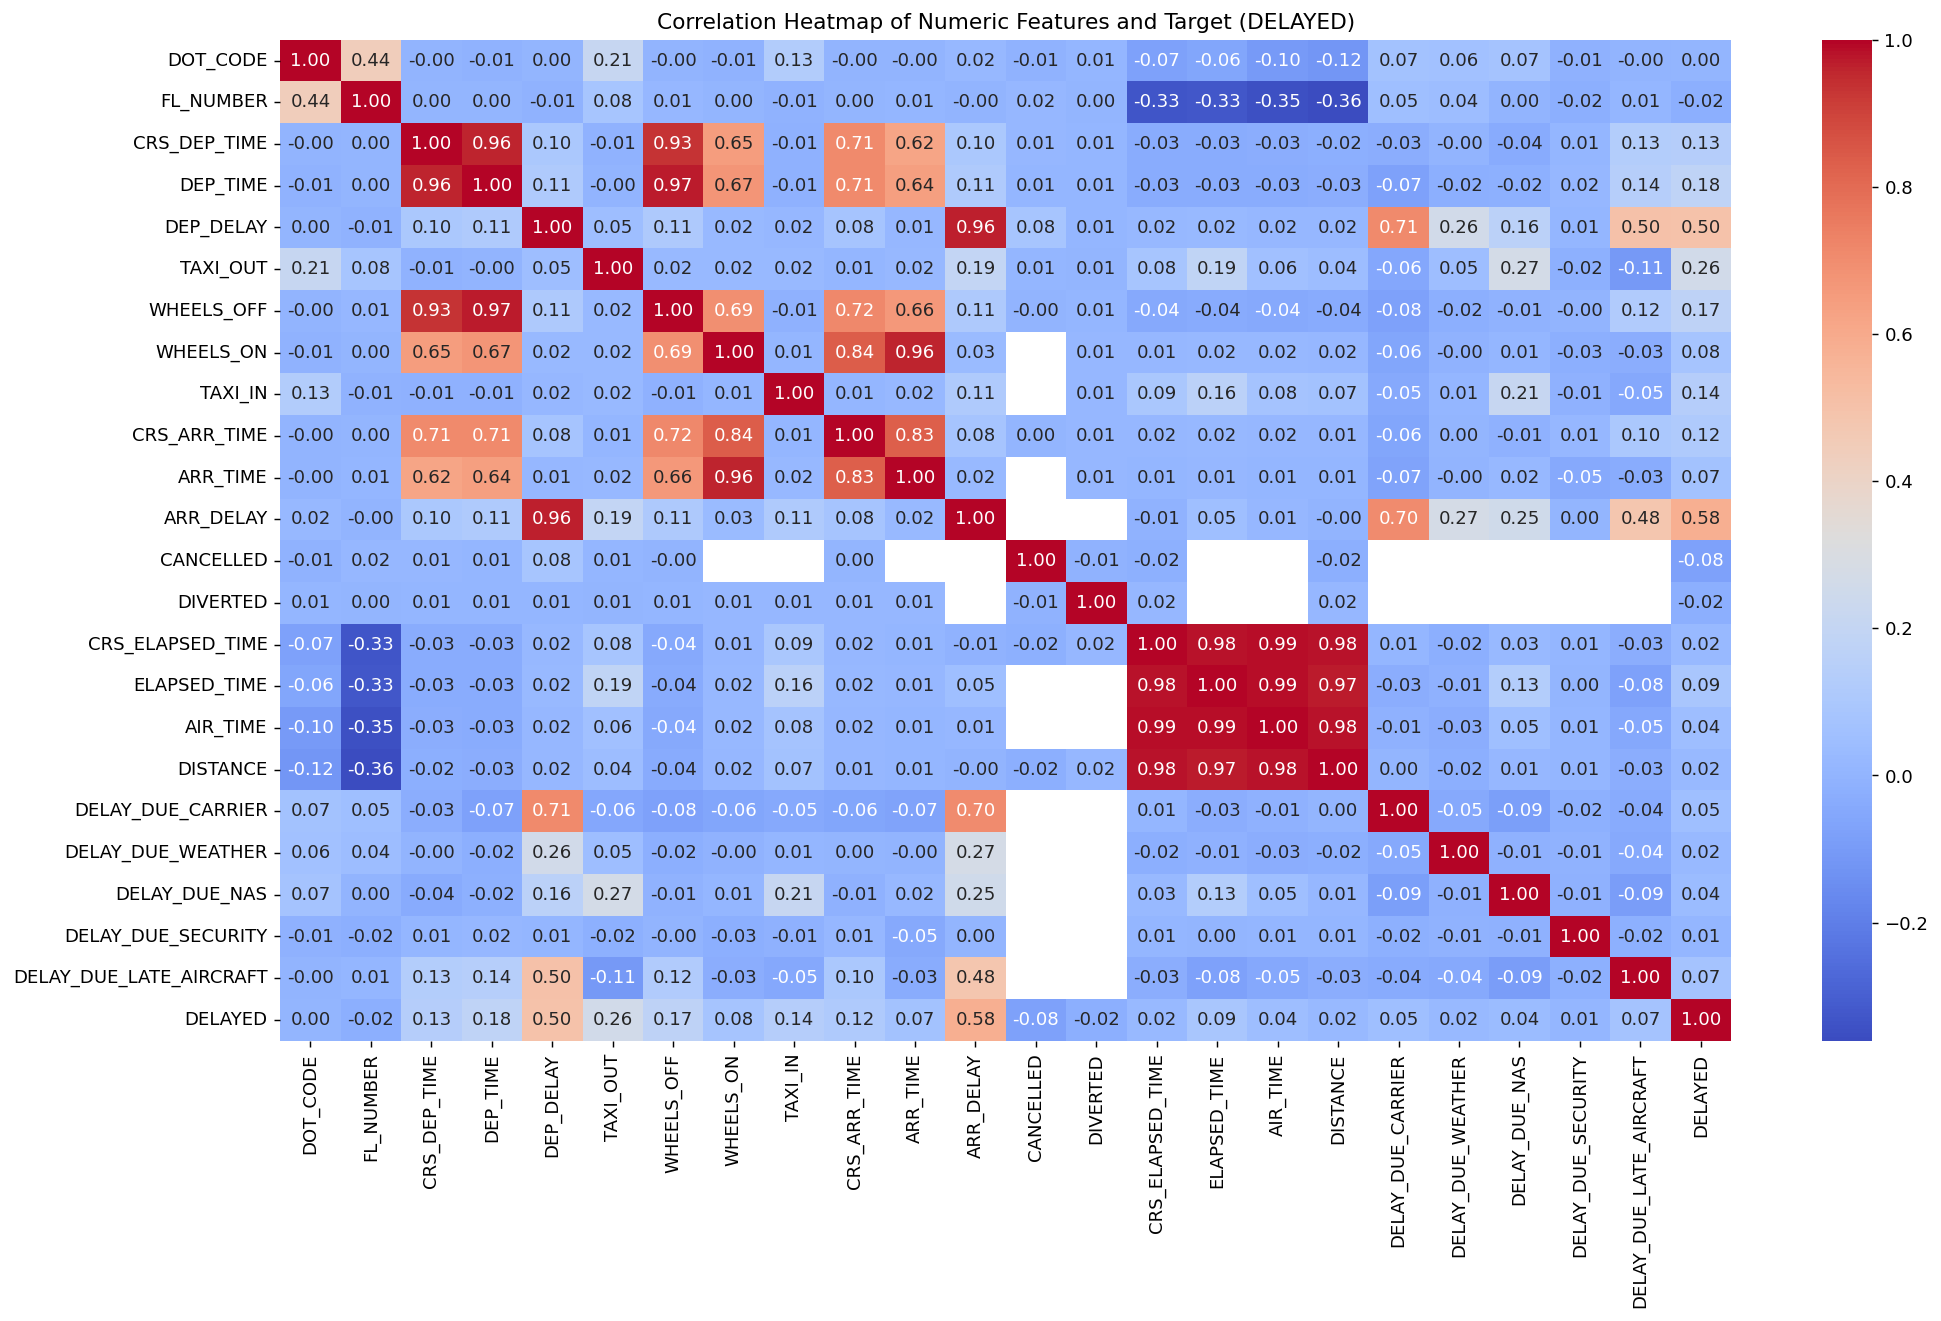

In [36]:
numeric_and_target_cols = df.select_dtypes(include=np.number).columns.tolist()

corr_df = df[numeric_and_target_cols]
corr = corr_df.corr()

plt.figure(figsize=(18, 10), dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features and Target (DELAYED)')
plt.show()

In [4]:
df['DELAYED'] = (df['ARR_DELAY'] > 15).astype(int)


In [5]:
COLUMNS_TO_DROP = [
        'ARR_DELAY', 
        'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 
        'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT', 
        'DELAYED'
]
X = df.drop(columns=COLUMNS_TO_DROP) 
y = df['DELAYED']

In [6]:
mask = y.notnull()
X = X.loc[mask].reset_index(drop=True)
y_clean = y.loc[mask].reset_index(drop=True).astype(int)

print(f"Cleaned X shape: {X.shape}")
print(f"Cleaned y shape: {y_clean.shape}")

Cleaned X shape: (30000, 26)
Cleaned y shape: (30000,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean, 
    test_size=0.2, 
    stratify=y_clean, # Maintain the proportion of delayed/on-time flights
    random_state=42
)
print(f"\nTrain set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")



Train set size: 24000 rows
Test set size: 6000 rows


In [10]:
from sklearn.base import BaseEstimator, TransformerMixin

class MultiColumnLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, **kwargs):
        self.encoders = {}

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        
        for i, col in enumerate(X_df.columns):
            unique_values = X_df[col].astype('category').cat.categories
            mapping = {val: i for i, val in enumerate(unique_values)}
            self.encoders[i] = mapping
        return self

    def transform(self, X):
        X_copy = pd.DataFrame(X).copy()
        
        for i, col in enumerate(X_copy.columns):
            X_copy[col] = X_copy[col].map(self.encoders[i]).fillna(-1).astype(int)
            
        return X_copy.values 

    def get_feature_names_out(self, input_features=None):
        return input_features


In [11]:
numeric_cols = [
    'DOT_CODE', 'FL_NUMBER', 'CRS_DEP_TIME', 'DEP_TIME', 'TAXI_OUT', 
    'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 
    'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE'
] # 14 columns

categorical_cols = [
    'FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'ORIGIN', 
    'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CANCELLATION_CODE', 'CANCELLED', 'DIVERTED'
] # 11 columns


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical Pipeline (Uses the corrected MultiColumnLabelEncoder)
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('labelenc', MultiColumnLabelEncoder()) 
])


In [22]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    # Drop any columns not specified above
    remainder='drop' 
)
print("\nPreprocessor (ColumnTransformer) defined successfully.")



Preprocessor (ColumnTransformer) defined successfully.


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
        'logistic_regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced', 
        random_state=42, 
        solver='liblinear'
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=100, 
        n_jobs=-1, 
        class_weight='balanced', 
        random_state=42
    )
}


In [24]:
pipelines = {}
for name, clf in models.items():
    pipelines[name] = Pipeline(steps=[('preprocessor', preprocessor), ('clf', clf)])

trained = {}
print("\nStarting model training...")
for name, pipe in pipelines.items():
    print(f"\nTraining {name}...")
    pipe.fit(X_train, y_train) 
    
    trained[name] = pipe
    print(f"Done training {name}.")

print("\nAll models trained successfully!")



Starting model training...

Training logistic_regression...
Done training logistic_regression.

Training random_forest...
Done training random_forest.

All models trained successfully!


In [26]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, roc_auc_score

print("\n--- Model Evaluation Results ---")
for name, pipe in trained.items():
    preds = pipe.predict(X_test)
    probs = None
    
    try:
        # Get probabilities for ROC AUC score (if supported by the classifier)
        probs = pipe.predict_proba(X_test)[:, 1]
    except Exception:
        probs = None
        
    print(f"\nModel: {name}")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(f"F1 Score: {f1_score(y_test, preds):.4f}")
    if probs is not None:
        print(f"ROC AUC: {roc_auc_score(y_test, probs):.4f}")
    
    # Print detailed reports
    print("\nConfusion matrix:\n", confusion_matrix(y_test, preds))
    print("\nClassification report:\n", classification_report(y_test, preds))



--- Model Evaluation Results ---

Model: logistic_regression
Accuracy: 0.7378
F1 Score: 0.4684
ROC AUC: 0.7784

Confusion matrix:
 [[3734 1223]
 [ 350  693]]

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.75      0.83      4957
           1       0.36      0.66      0.47      1043

    accuracy                           0.74      6000
   macro avg       0.64      0.71      0.65      6000
weighted avg       0.82      0.74      0.76      6000


Model: random_forest
Accuracy: 0.9147
F1 Score: 0.6897
ROC AUC: 0.9768

Confusion matrix:
 [[4919   38]
 [ 474  569]]

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95      4957
           1       0.94      0.55      0.69      1043

    accuracy                           0.91      6000
   macro avg       0.92      0.77      0.82      6000
weighted avg       0.92      0.91      0.91      6000



In [29]:
import joblib
import os
random_forest_pipeline = trained['random_forest']

model_filename = 'flight_delay_random_forest_pipeline.joblib'

joblib.dump(random_forest_pipeline, model_filename)
print(f"\n✅ Random Forest model pipeline successfully saved to '{os.path.abspath(model_filename)}'")


✅ Random Forest model pipeline successfully saved to 'C:\Users\turni\OneDrive\Desktop\flight\Flight 2.0\flight_delay_random_forest_pipeline.joblib'
